<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/05_ConvNeXt_Tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Imports

In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.applications import ConvNeXtTiny

Step 2 — Dataset paths and classes

In [ ]:
dataset_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes 500"

classes = [
    "kitchen",
    "bedroom",
    "casino",
    "warehouse",
    "inside_subway"
]

image_size = (224, 224)
batch_size = 32

train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")
test_dir = os.path.join(dataset_dir, "test")

print("Dataset exists:", os.path.exists(dataset_dir))
print("Training directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(validation_dir))
print("Test directory exists:", os.path.exists(test_dir))

Dataset exists: True
Training directory exists: True
Validation directory exists: True
Test directory exists: True


Step 3 — Load the same datasets

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 2500 files belonging to 5 classes.
Found 431 files belonging to 5 classes.
Found 434 files belonging to 5 classes.


Step 4 — Prefetch

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Step 5 — Load ConvNeXt-Tiny

In [ ]:
base_model = ConvNeXtTiny(
    include_top=False,
    weights="imagenet", # Use pretrained ImageNet weights for transfer learning
    input_shape=(224, 224, 3)
)

base_model.trainable = False #pretrained feature-extraction layers are frozen initially

print("ConvNeXt-Tiny loaded successfully.")
print("Base model trainable:", base_model.trainable)

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ConvNeXt-Tiny loaded successfully.
Base model trainable: False


Step 6 — Build the classification model

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    5,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

print("ConvNeXt-Tiny model created successfully.")

ConvNeXt-Tiny model created successfully.


Step 7 — Check the model

In [ ]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         3,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,823,973 (106.14 MB)

 Trainable params: 3,845 (15.02 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

Step 8 - Compile

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Step 9 — Callbacks

In [ ]:
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/convnext_tiny_balanced500_best.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks configured.")

Callbacks configured.


Step 10 — Train

In [ ]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 333s 4s/step - accuracy: 0.8256 - loss: 0.5925 - val_accuracy: 0.9722 - val_loss: 0.1627
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step - accuracy: 0.9812 - loss: 0.1381 - val_accuracy: 0.9838 - val_loss: 0.1013
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 208ms/step - accuracy: 0.9836 - loss: 0.0930 - val_accuracy: 0.9814 - val_loss: 0.0811
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 209ms/step - accuracy: 0.9848 - loss: 0.0728 - val_accuracy: 0.9768 - val_loss: 0.0697
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step - accuracy: 0.9900 - loss: 0.0576 - val_accuracy: 0.9838 - val_loss: 0.0623
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 209ms/step - accuracy: 0.9920 - loss: 0.0488 - val_accuracy: 0.9838 - val_loss: 0.0577
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - accuracy: 0.9928 - loss: 0.0413 - val_accuracy: 0.9814 - val_loss: 0.0545
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 207ms/step - accuracy: 0.9920 - loss: 0.0403 - val_accura

Step 11 — Plot the learning curves

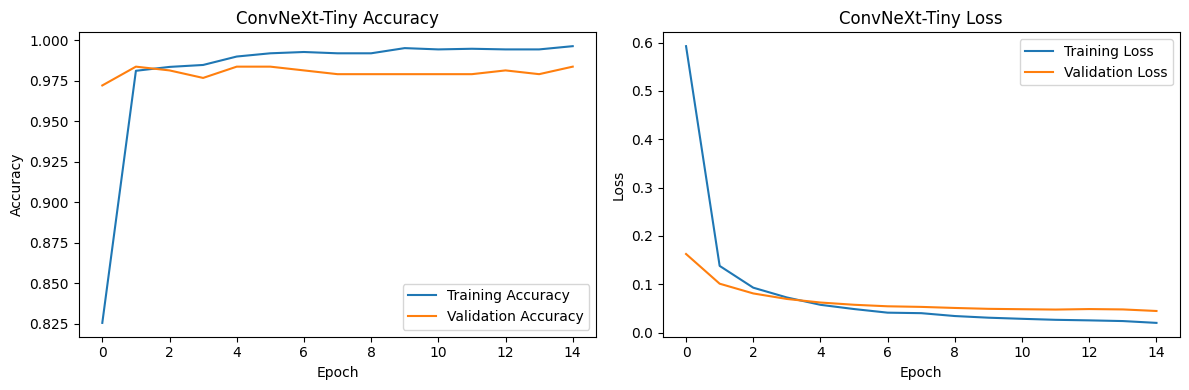

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ConvNeXt-Tiny Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ConvNeXt-Tiny Loss")
plt.legend()

plt.tight_layout()
plt.show()

Step 12 — Test evaluation

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 66s 5s/step - accuracy: 0.9839 - loss: 0.0440
Test Loss: 0.04402279481291771
Test Accuracy: 0.9838709831237793


Step 13 - Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
))

               precision    recall  f1-score   support

      kitchen     0.9818    0.9730    0.9774       111
      bedroom     0.9800    0.9800    0.9800       100
       casino     0.9750    1.0000    0.9873        78
    warehouse     0.9868    0.9868    0.9868        76
inside_subway     1.0000    0.9855    0.9927        69

     accuracy                         0.9839       434
    macro avg     0.9847    0.9851    0.9849       434
 weighted avg     0.9839    0.9839    0.9839       434



Step 14 - Confusion Matrix

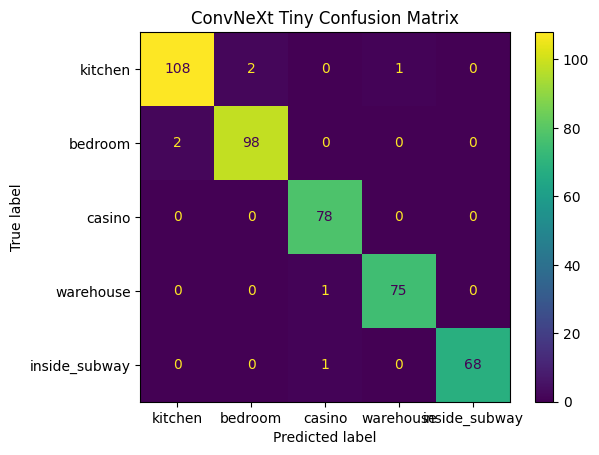

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()
plt.title("ConvNeXt-Tiny Confusion Matrix")
plt.show()

In [ ]:
print("ConvNeXt-Tiny Final Results")
print("----------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")
print(f"Correct Predictions: {sum(np.array(y_true) == np.array(y_pred))}")
print(f"Incorrect Predictions: {sum(np.array(y_true) != np.array(y_pred))}")

ConvNeXt-Tiny Final Results
----------------------------
Test Loss: 0.0440
Test Accuracy: 98.3871%
Correct Predictions: 427
Incorrect Predictions: 7
